In [ ]:
!pip install google-generativeai langchain langchain-core graphviz

In [2]:
import google.generativeai as genai
from getpass import getpass
from langchain.prompts import ChatPromptTemplate
from langchain.schema.output_parser import StrOutputParser
from langchain_core.runnables import RunnableSequence, RunnableLambda, RunnableParallel, RunnablePassthrough
from langchain.memory import ConversationBufferMemory
from graphviz import Digraph
import random

In [31]:
api_key = getpass("🔑 Enter your Gemini API key: ")
genai.configure(api_key=api_key)

# Create a custom LLM class that wraps Gemini for LangChain compatibility
from langchain_core.language_models.llms import LLM
from typing import Optional, List, Mapping, Any

class GeminiLLM(LLM):
    model_name: str = "gemini-2.5-flash"

    @property
    def _llm_type(self) -> str:
        return "gemini"

    def _call(self, prompt: str, stop: Optional[List[str]] = None, **kwargs) -> str:
        model = genai.GenerativeModel(self.model_name)
        response = model.generate_content(prompt)
        return response.text

    @property
    def _identifying_params(self) -> Mapping[str, Any]:
        return {"model_name": self.model_name}

model = GeminiLLM()

In [18]:
# cell 3 - Create basic_chain with proper imports
from langchain_core.runnables import RunnableSequence, RunnableLambda
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.language_models.llms import LLM

# Basic prompt → model → parser
prompt_basic = ChatPromptTemplate.from_template("Write a short motivational quote about {topic}.")
parser_basic = StrOutputParser()

# Add a conversion step to turn ChatPromptValue into string
def prompt_to_string(prompt_value):
    if hasattr(prompt_value, 'to_string'):
        return prompt_value.to_string()
    elif hasattr(prompt_value, 'content'):
        return prompt_value.content
    else:
        return str(prompt_value)

string_converter = RunnableLambda(prompt_to_string)

# Create basic_chain step by step to ensure each component is wrapped
step1 = RunnableLambda(lambda x: prompt_basic.invoke(x))
step2 = string_converter
step3 = RunnableLambda(lambda x: model.invoke(x))
step4 = parser_basic

# Now create the sequence
basic_chain = RunnableSequence(
    first=step1,
    middle=[step2, step3],
    last=step4
)

print("Basic chain created successfully!")
print(f"Basic chain type: {type(basic_chain)}")

Basic chain created successfully!
Basic chain type: <class 'langchain_core.runnables.base.RunnableSequence'>


In [19]:
# Modular Runnables
preprocess = RunnableLambda(lambda x: {"topic": x["topic"].title()})
postprocess = RunnableLambda(lambda x: x + " ✨")  # add flair
modular_chain = RunnableSequence(
    first=preprocess,
    middle=[RunnableLambda(lambda x: basic_chain.invoke(x))],
    last=postprocess
)

In [20]:
# For different topics per branch
branch1 = RunnableLambda(lambda x: modular_chain.invoke({"topic": x["topic1"]}))
branch2 = RunnableLambda(lambda x: modular_chain.invoke({"topic": x["topic2"]}))

parallel_chain = RunnableParallel({"branch1": branch1, "branch2": branch2})

# Inputs with different topics
parallel_inputs = {
    "topic1": "focus",
    "topic2": "happiness"
}

# Invoke
parallel_results = parallel_chain.invoke(parallel_inputs)
print("Parallel Results:", parallel_results)

Parallel Results: {'branch1': '"Focus isn\'t about narrowing your world; it\'s about magnifying your potential." ✨', 'branch2': 'Cultivate joy from within, and happiness will bloom in every moment. ✨'}


In [21]:
# Custom chain using RunnableLambda
custom_chain = RunnableLambda(lambda x: modular_chain.invoke({"topic": x["topic"].upper()}))
custom_result = custom_chain.invoke({"topic": "perseverance"})
print("Custom Chain Result:", custom_result)

Custom Chain Result: "Perseverance isn't about never falling, but always rising." ✨


In [22]:
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=False)

# Prompt uses memory
prompt_memory = ChatPromptTemplate.from_template(
    "Conversation so far:\n{chat_history}\nUser: {user_input}\nAI:"
)

memory_chain = RunnableSequence(
    first=RunnablePassthrough(),
    middle=[prompt_memory, model],
    last=StrOutputParser()
)

# Simulate conversation
user_msgs = ["Hello!", "How are you?", "Give me motivation."]
for msg in user_msgs:
    mem_vars = memory.load_memory_variables({})
    input_dict = {"user_input": msg, "chat_history": mem_vars["chat_history"]}
    response = memory_chain.invoke(input_dict)
    print("AI:", response)
    memory.save_context({"user_input": msg}, {"output": response})

AI: Hi! How can I help you today?
AI: As an AI, I don't have feelings, but I'm functioning perfectly! Thanks for asking. How are you doing today?
AI: Absolutely! You've got this.

Remember that every single day is a new opportunity to make progress, no matter how small. You possess incredible strength and potential, even if you don't always feel it. Don't be afraid to take that first step, or to keep going when things get tough. Your resilience is stronger than any obstacle.

Believe in yourself, trust your journey, and know that you are capable of achieving amazing things. Keep pushing forward, keep learning, and keep growing. Your future self will thank you. Now go out there and make it happen!


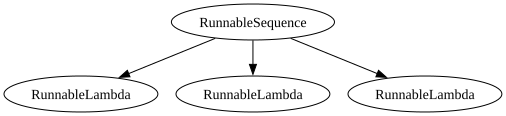

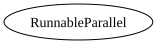

In [23]:
def visualize_chain(chain, graph=None, parent=None, name="root"):
    if graph is None:
        graph = Digraph(comment="LangChain Graph")
    graph.node(name, type(chain).__name__)
    if parent:
        graph.edge(parent, name)
    if isinstance(chain, RunnableSequence):
        if chain.first:
            visualize_chain(chain.first, graph, parent=name, name=name+"_first")
        for i, mid in enumerate(chain.middle):
            visualize_chain(mid, graph, parent=name, name=f"{name}_mid{i}")
        if chain.last:
            visualize_chain(chain.last, graph, parent=name, name=name+"_last")
    elif isinstance(chain, RunnableParallel):
        branches = getattr(chain, "steps__", {})
        for branch_name, branch_runnable in branches.items():
            visualize_chain(branch_runnable, graph, parent=name, name=f"{name}_{branch_name}")
    return graph

graph1 = visualize_chain(modular_chain)
graph2 = visualize_chain(parallel_chain)

display(graph1)
display(graph2)

In [32]:
def evaluate_chain(chain, topics):
    results = []
    for topic in topics:
        output = chain.invoke({"topic": topic})
        score = len(output.split())  # simple metric: number of words
        results.append({"topic": topic, "output": output, "score": score})
    return results

topics = ["focus", "happiness", "perseverance"]
eval_results = evaluate_chain(modular_chain, topics)

for r in eval_results:
    print(f"Topic: {r['topic']}, Score: {r['score']}, Output: {r['output']}")

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 

## Features in Workflow

1	Basic prompt → model → parser

2	Modular RunnableSequences with preprocessing/postprocessing

3	Parallel chains and concurrency

4	Custom logic with RunnableLambda

5	Memory for stateful conversations

6	Graph visualization of chains

7	Evaluation and scoring of outputs